In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [3]:
rainbow = cv2.imread("data/rainbow.jpg")
show_rainbow = cv2.cvtColor(rainbow, cv2.COLOR_BGR2RGB)

img = rainbow
img.shape

(550, 413, 3)

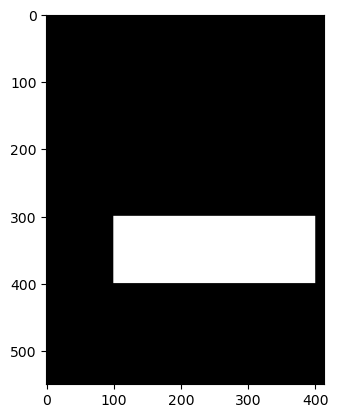

In [8]:
# Creating mask

mask = np.zeros(img.shape[:2], np.uint8)
# Ignoring colour channels

# Creating an ROI for masking
mask[300:400, 100:400] = 255

plt.imshow(mask, cmap = "gray")

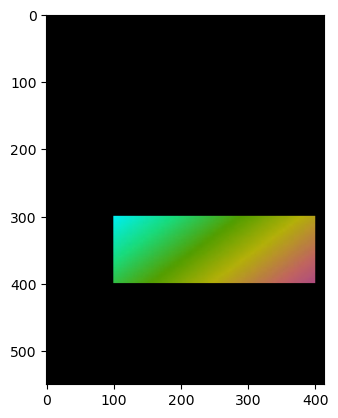

In [11]:
masked_img = cv2.bitwise_and(img, img, mask=mask)
show_masked_img = cv2.bitwise_and(show_rainbow, show_rainbow, mask=mask)

plt.imshow(masked_img, cmap = "gray")

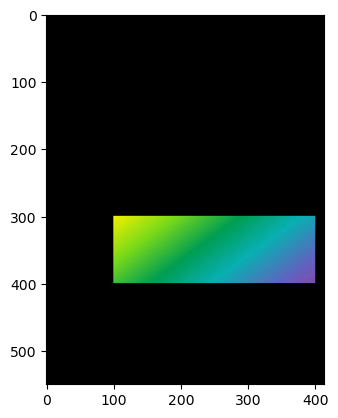

In [12]:
plt.imshow(show_masked_img, cmap = "gray")

In [15]:
# Calculating Histogram masked values for Red channel

hist_mask_values_red = cv2.calcHist([rainbow], channels=[2], mask=mask, histSize=[256], ranges=[0, 256])

#One more without masking - Just to compare
hist_values_red = cv2.calcHist([rainbow], channels=[2], mask=None, histSize=[256], ranges=[0, 256])

Text(0.5, 1.0, 'Red histogram for masked Rainbow')

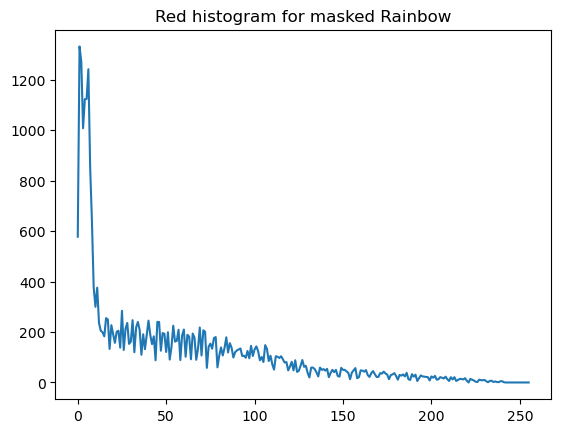

In [16]:
plt.plot(hist_mask_values_red)
plt.title("Red histogram for masked Rainbow")

Text(0.5, 1.0, 'Red histogram for original Rainbow')

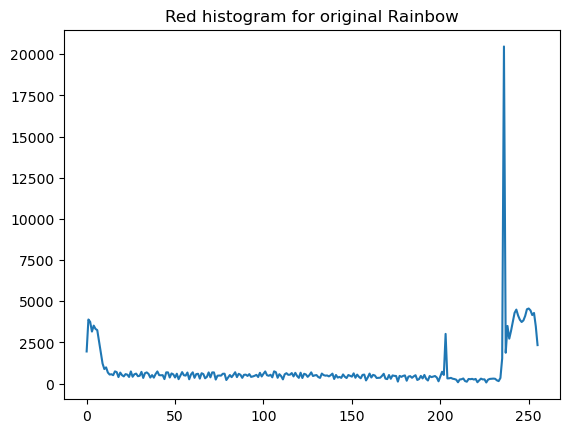

In [18]:
plt.plot(hist_values_red)
plt.title("Red histogram for original Rainbow")

In [32]:
# Histogram Equalization

# Upload image as greyscale
gorilla = cv2.imread("data/gorilla.jpg", 0)
gorilla.shape

(1295, 1955)

In [30]:
def display_img(img, cmap=None):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111)
    ax.imshow(img, cmap)

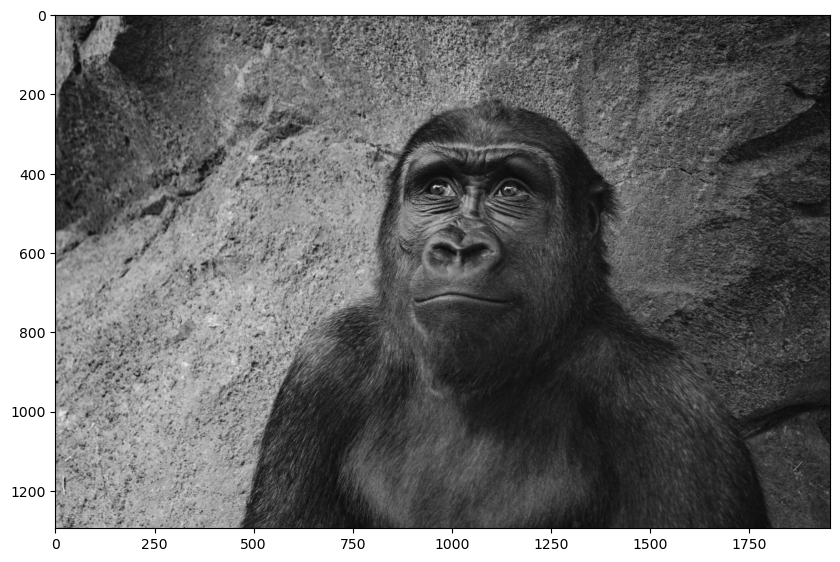

In [31]:
display_img(gorilla, cmap = "gray")

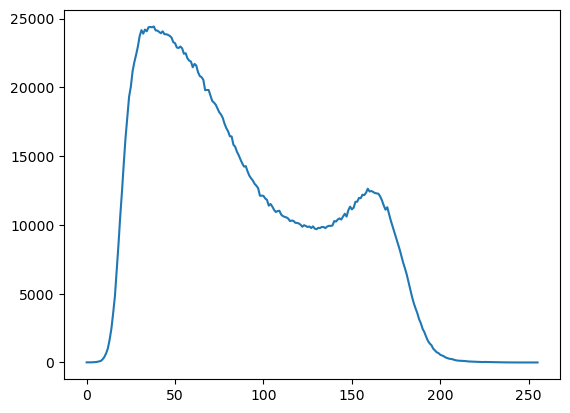

In [33]:
# Calculate histogram
hist_values = cv2.calcHist([gorilla], channels=[0], mask=None, histSize=[256], ranges=[0, 256])
plt.plot(hist_values)

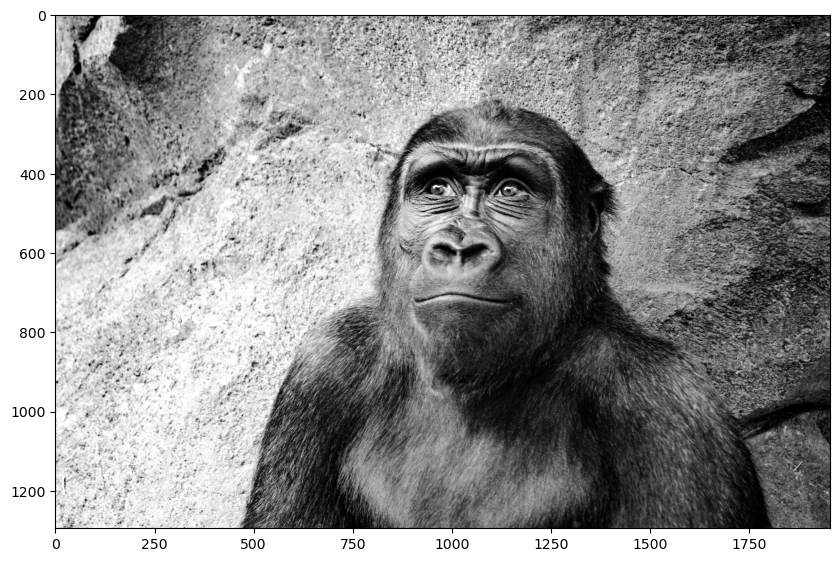

In [34]:
# Equalizing histogram
eq_gorilla = cv2.equalizeHist(gorilla)
display_img(eq_gorilla, cmap = "gray")

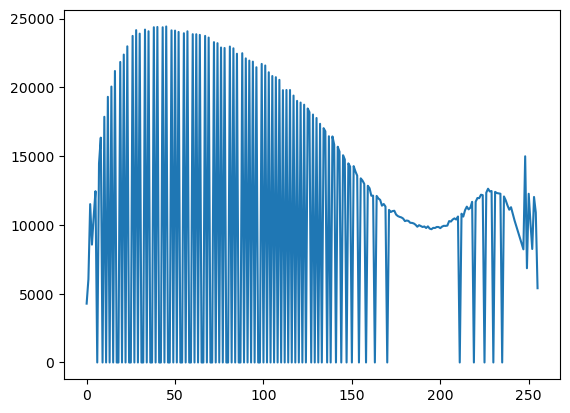

In [35]:
# Check histogram
hist_values = cv2.calcHist([eq_gorilla], channels=[0], mask=None, histSize=[256], ranges=[0, 256])
plt.plot(hist_values)

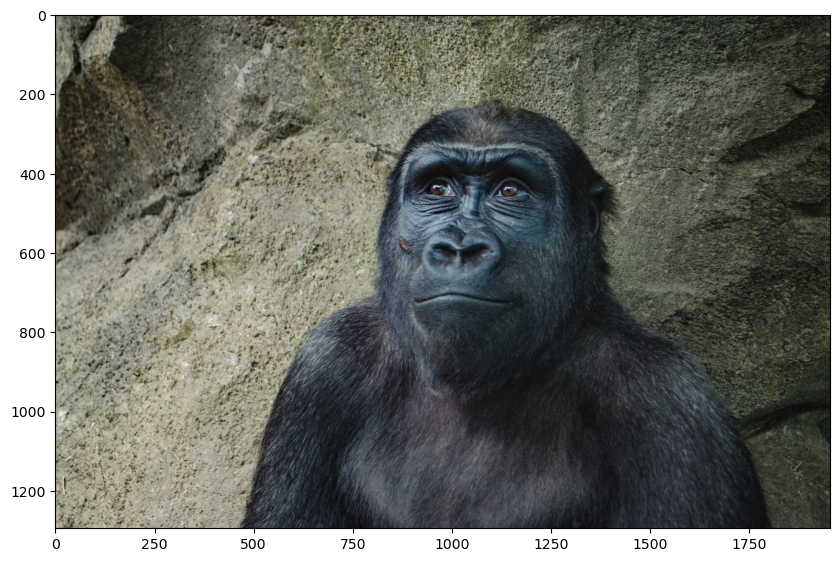

In [38]:
# Same activity for a coloured image

color_gorilla = cv2.imread("data/gorilla.jpg")
show_gorilla = cv2.cvtColor(color_gorilla, cv2.COLOR_BGR2RGB)
display_img(show_gorilla)

1
255


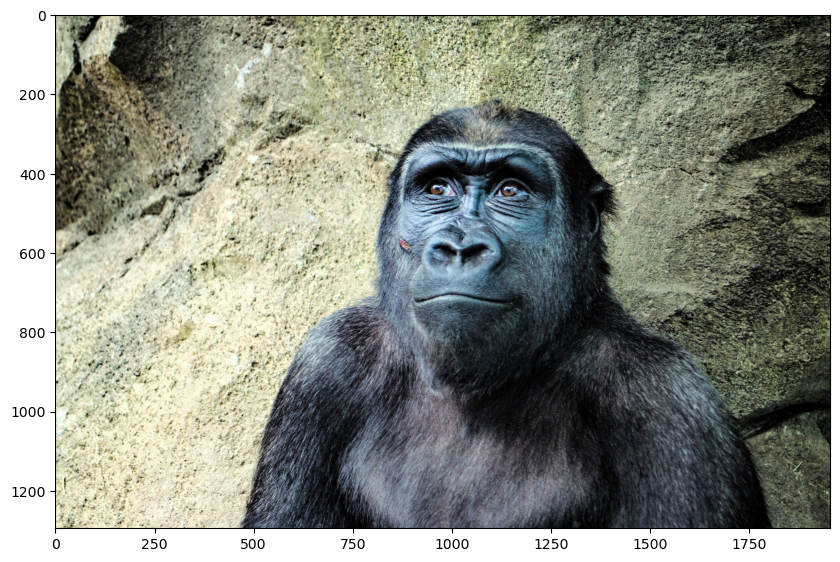

In [41]:
# To increase the contrast of a coloured image, translate that first to HSV colour scale (Hue, Saturation, Value)

hsv = cv2.cvtColor(color_gorilla, cv2.COLOR_BGR2HSV)
# Check the value channel
print(hsv[:,:,2].min())
print(hsv[:,:,2].max())

# Now equalize
hsv[:,:,2] = cv2.equalizeHist(hsv[:,:,2])

# Now view the equalized image
eq_color_gorilla = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)

display_img(eq_color_gorilla)